<a href="https://colab.research.google.com/github/Priya-Kumari-Chourasia/ml_algo/blob/main/perceptron_trick.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
from sklearn.datasets import make_classification
import numpy as np

# Generates a random N-class classification dataset.
# This is very useful for testing classification algorithms.
x,y = make_classification(
    n_samples=100,          # Total number of samples (data points) to generate.
    n_features=2,           # Total number of features (columns) for each sample.
    n_informative=1,         # Number of informative features. These contribute to the target variable.
    n_redundant=0,           # Number of redundant features. These are linear combinations of informative features.
    n_classes=2,             # Number of target classes (e.g., 0 and 1 for binary classification).
    n_clusters_per_class=1,  # The number of clusters per class.
    random_state=42,         # Seed for random number generation for reproducibility.
    hypercube=False,         # If true, samples are drawn uniformly from a hypercube. If false, drawn from a Gaussian.
    class_sep=3          # How separable the classes are. Higher values mean more separation.
)
# x: This is a 2D array representing the features of the dataset (1000 samples, 20 features).
# y: This is a 1D array representing the target labels (classes) for each sample (1000 labels, either 0 or 1).

In [3]:
import matplotlib.pyplot as plt

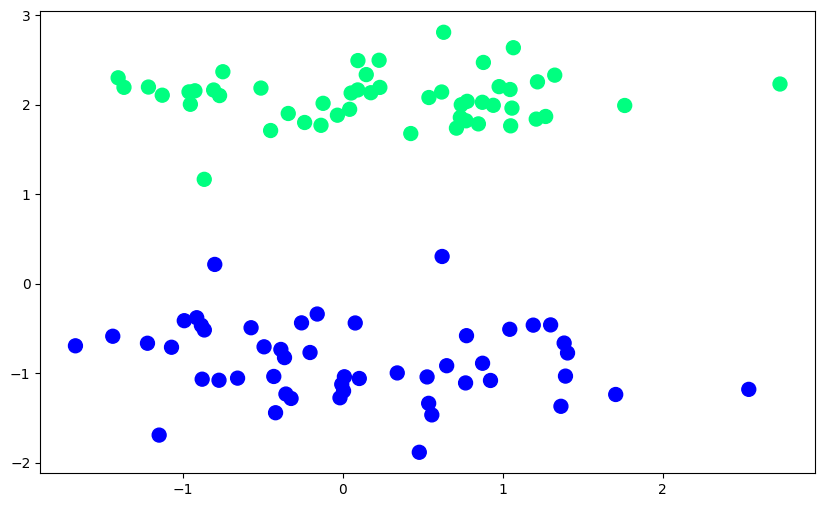

In [4]:
plt.figure(figsize=(10,6))
plt.scatter(x[:,0],x[:,1],c=y,cmap='winter',s=100)

In [5]:
def perceptron(x,y):
  x = np.insert(x,0,1,axis=1)
  weights = np.ones(x.shape[1])
  lr=0.1

  for i in range(1000):
    j = np.random.randint(0,100)
    y_hat = step(np.dot(x[j],weights))
    weights = weights + lr*(y[j]-y_hat)*x[j]

  return weights[0],weights[1:]


In [6]:
def step(z):
  return 1 if z>0 else 0

In [7]:
intercept_,coef_=perceptron(x,y)

In [8]:
print(coef_)
print(intercept_)

[0.10664928 1.21831377]
-0.4999999999999999


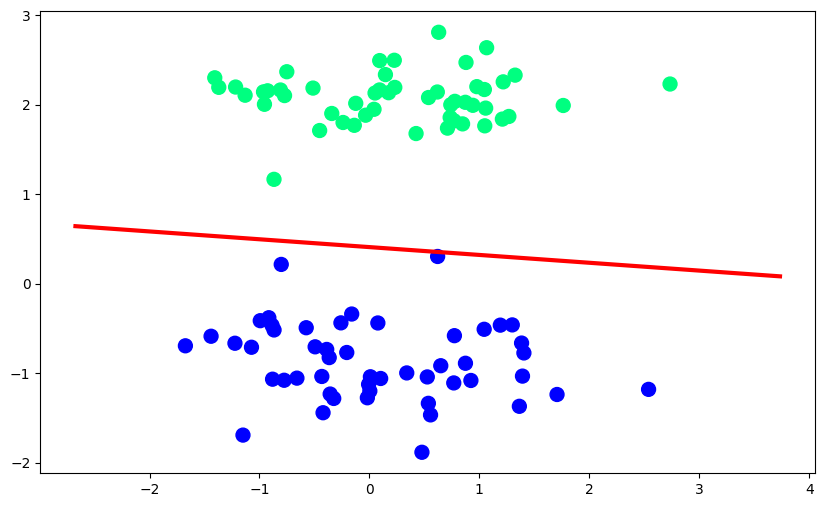

In [12]:
plt.figure(figsize=(10,6))
x_input = np.linspace(x[:,0].min()-1, x[:,0].max()+1, 100)
y_input = ((-coef_[0]*x_input) - intercept_)/coef_[1]
plt.plot(x_input,y_input,color='red',linewidth=3)
plt.scatter(x[:,0],x[:,1],c=y,cmap='winter',s=100)
